# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.



"""
============================================
PERKENALAN DATASET CREDIT RISK
============================================

Nama Dataset: Credit Risk Dataset
Sumber: Kaggle - laotse
Link: https://www.kaggle.com/datasets/laotse/credit-risk-dataset

Deskripsi Bisnis:
Dataset ini berisi informasi peminjam (borrower) untuk tugas credit scoring.
Tujuannya adalah memprediksi apakah seseorang akan mengalami kesulitan 
pembayaran pinjaman (default) atau tidak.

Fitur-fitur:
- person_age: Usia peminjam (tahun)
- person_income: Pendapatan tahunan (USD)
- person_home_ownership: Status kepemilikan rumah (RENT, OWN, MORTGAGE, OTHER)
- person_emp_length: Lama bekerja (tahun)
- loan_intent: Tujuan pinjaman (EDUCATION, MEDICAL, PERSONAL, etc)
- loan_grade: Grade pinjaman (A = terbaik, G = terburuk)
- loan_amnt: Jumlah pinjaman (USD)
- loan_int_rate: Suku bunga (%)
- loan_percent_income: Persentase pendapatan untuk cicilan
- cb_person_default_on_file: Riwayat default sebelumnya (Y/N)
- cb_person_cred_hist_length: Panjang sejarah kredit (tahun)

Target Variable:
- loan_status: 0 = Non-Default (lancar), 1 = Default (bermasalah)

Tujuan Proyek:
Membangun model machine learning untuk memprediksi probabilitas default
nasabah sebagai bagian dari sistem credit scoring.
"""


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
# Cell 2: Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Untuk handling imbalance data
from imblearn.over_sampling import SMOTE

# Untuk visualisasi di VS Code
import warnings
warnings.filterwarnings('ignore')

# Setting visualisasi (untuk VS Code)
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)

# Import display untuk menggantikan display() dari Colab
from IPython.display import display

print("✅ Library berhasil diimport!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {pd.__version__}")

✅ Library berhasil diimport!
Pandas version: 3.0.2
NumPy version: 2.4.4
Scikit-learn version: 3.0.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
import os

# Cek apakah file dataset ada
dataset_path = 'data_raw/credit_risk_dataset.csv'

if not os.path.exists(dataset_path):
    print(f"❌ ERROR: File tidak ditemukan di {dataset_path}")
    print("📁 Pastikan file CSV sudah ditempatkan di folder 'data_raw/'")
    print("📁 Struktur folder yang benar:")
    print("    Eksperimen_SML_Nama-siswa/")
    print("    ├── data_raw/")
    print("    │   └── credit_risk_dataset.csv")
    print("    ├── preprocessing/")
    print("    └── Eksperimen_Nama-siswa.ipynb")
else:
    # Load dataset
    df = pd.read_csv(dataset_path)
    
    print("="*60)
    print("✅ DATASET BERHASIL DIMUAT")
    print("="*60)
    
    # Cek informasi awal
    print(f"\n📊 Ukuran Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
    
    print("\n📋 5 Data Pertama:")
    display(df.head())
    
    print("\n📋 Informasi Dataset:")
    print(df.info())
    
    print("\n📊 Statistik Deskriptif:")
    display(df.describe())
    
    print("\n🔍 Cek Missing Values:")
    print(df.isnull().sum())
    
    print("\n🎯 Distribusi Target (loan_status):")
    print(df['loan_status'].value_counts())
    print(f"Persentase Default: {df['loan_status'].mean()*100:.2f}%")

✅ DATASET BERHASIL DIMUAT

📊 Ukuran Dataset: 32581 baris, 12 kolom

📋 5 Data Pertama:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



📋 Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None

📊 Statistik Deskri

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000



🔍 Cek Missing Values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

🎯 Distribusi Target (loan_status):
loan_status
0    25473
1     7108
Name: count, dtype: int64
Persentase Default: 21.82%


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

🔍 EXPLORATORY DATA ANALYSIS (EDA)

----------------------------------------
1️⃣ MISSING VALUES ANALYSIS
----------------------------------------


,Missing Values,Percentage (%)
loan_int_rate,3116,9.563856
person_emp_length,895,2.747000



----------------------------------------
2️⃣ DUPLICATE DATA
----------------------------------------
Jumlah data duplikat: 165

----------------------------------------
3️⃣ TARGET VARIABLE ANALYSIS (loan_status)
----------------------------------------


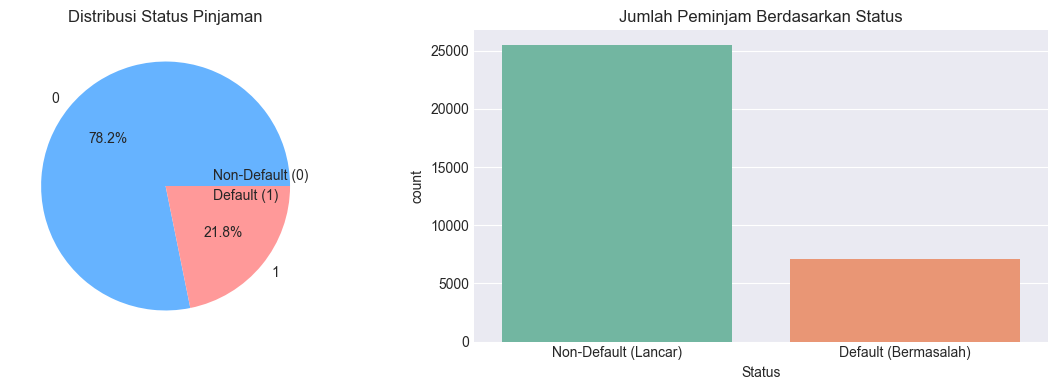


----------------------------------------
4️⃣ RISK FACTOR ANALYSIS
----------------------------------------


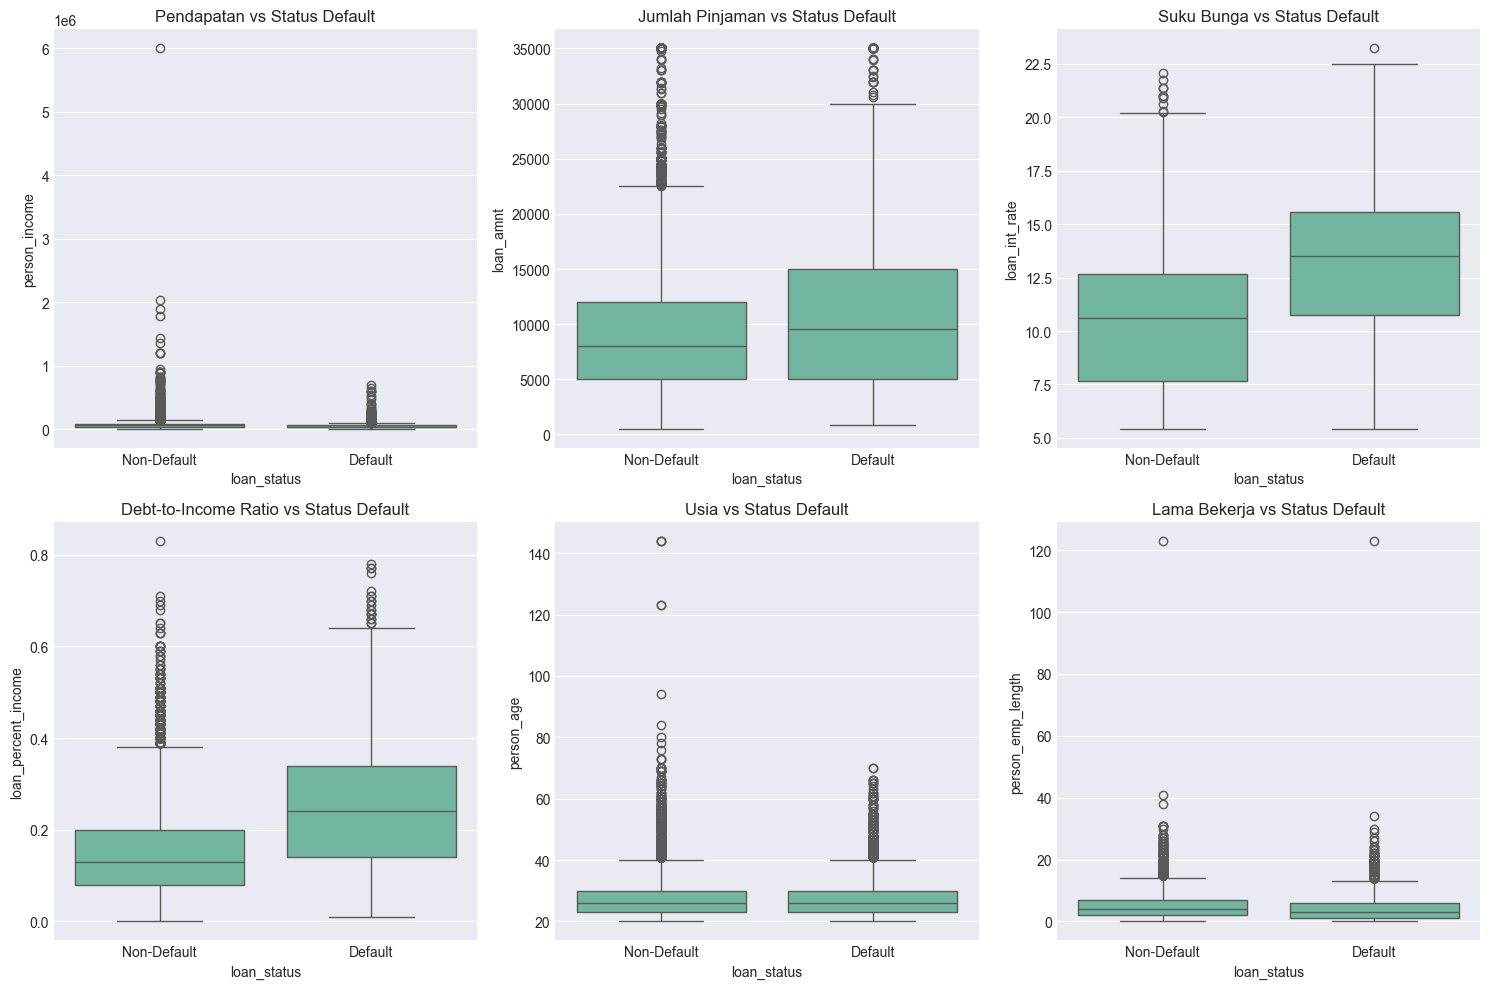


----------------------------------------
5️⃣ CATEGORICAL FEATURES ANALYSIS
----------------------------------------


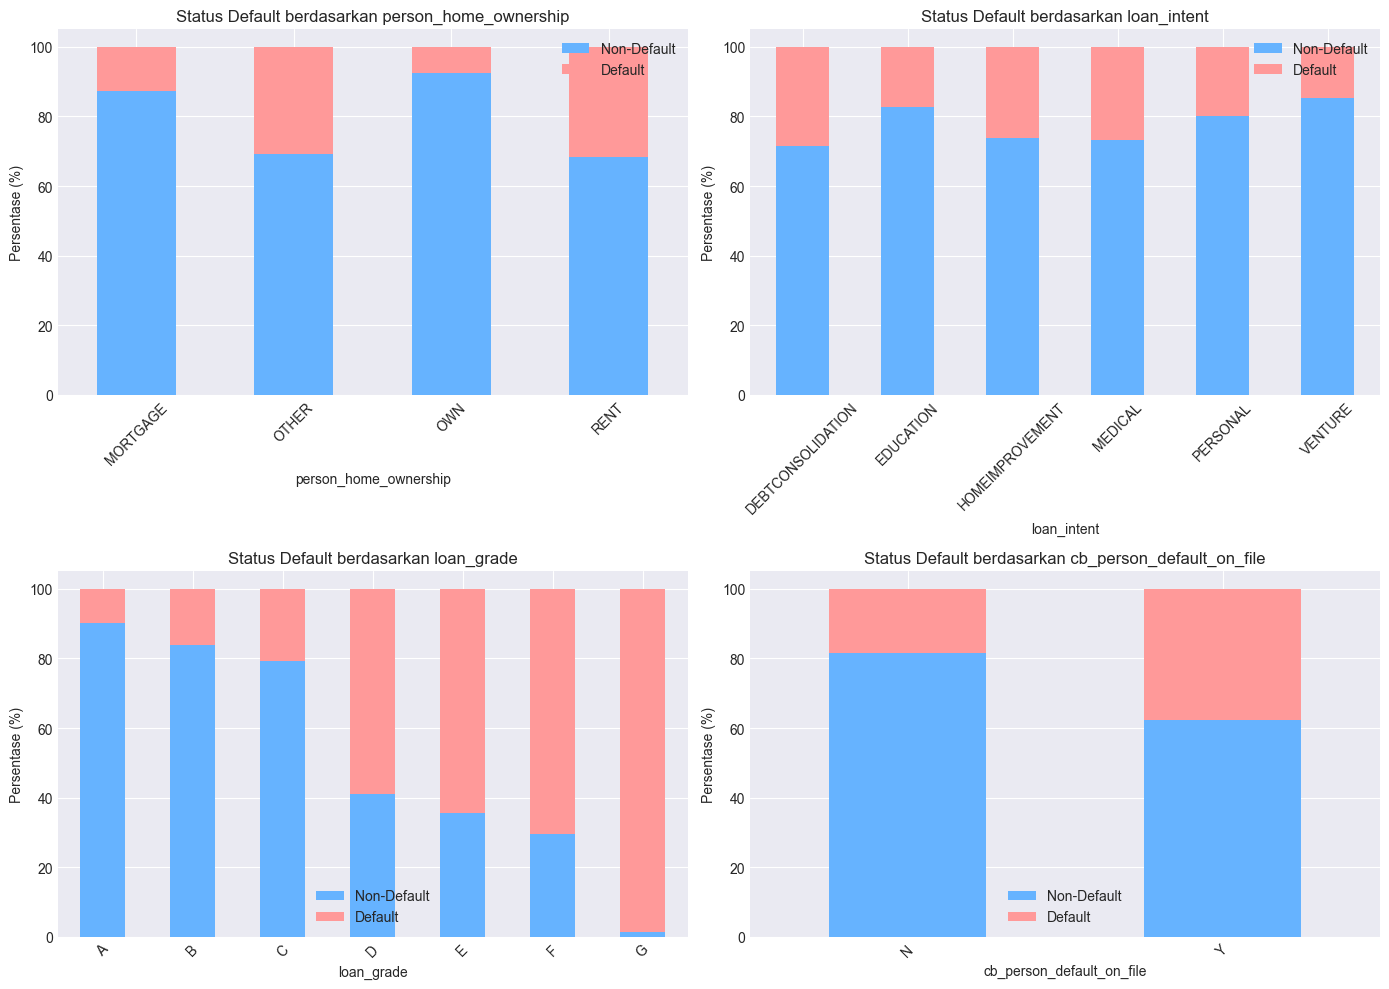


----------------------------------------
📝 RINGKASAN INSIGHT EDA
----------------------------------------

    ✅ INSIGHT UNTUK CREDIT SCORING:

    1. TARGET IMBALANCE:
       - Dataset tidak seimbang (default ~20% atau kurang)
       - Perlu teknik handling imbalance: SMOTE atau class_weight

    2. FAKTOR RISIKO UTAMA:
       - loan_percent_income (DTI): Semakin tinggi, semakin besar risiko default
       - loan_int_rate: Suku bunga tinggi = risiko tinggi
       - person_emp_length: Lama kerja pendek (<2 tahun) risiko lebih tinggi

    3. FAKTOR PROTECTIVE:
       - person_income: Pendapatan tinggi cenderung lebih aman
       - loan_grade: Grade A/B memiliki default rate rendah

    4. BUSINESS IMPLICATION:
       - False Positive (menolak nasabah baik) = kehilangan revenue
       - False Negative (menyetujui nasabah buruk) = potensi kerugian
    


In [6]:
# Pastikan df sudah didefinisikan di cell sebelumnya
if 'df' not in dir():
    print("❌ Error: Dataset belum dimuat. Jalankan Cell 3 terlebih dahulu!")
else:
    print("="*60)
    print("🔍 EXPLORATORY DATA ANALYSIS (EDA)")
    print("="*60)
    
    # 4.1 Cek Missing Values Detail
    print("\n" + "-"*40)
    print("1️⃣ MISSING VALUES ANALYSIS")
    print("-"*40)
    
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Values': missing,
        'Percentage (%)': missing_pct
    })
    display(missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False))
    
    # 4.2 Cek Data Duplikat
    print("\n" + "-"*40)
    print("2️⃣ DUPLICATE DATA")
    print("-"*40)
    print(f"Jumlah data duplikat: {df.duplicated().sum()}")
    
    # 4.3 Analisis Target Variable
    print("\n" + "-"*40)
    print("3️⃣ TARGET VARIABLE ANALYSIS (loan_status)")
    print("-"*40)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Pie chart
    colors = ['#66b3ff', '#ff9999']
    df['loan_status'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                            colors=colors, ax=axes[0])
    axes[0].set_title('Distribusi Status Pinjaman')
    axes[0].set_ylabel('')
    axes[0].legend(['Non-Default (0)', 'Default (1)'])
    
    # Count plot
    sns.countplot(data=df, x='loan_status', ax=axes[1], palette='Set2')
    axes[1].set_title('Jumlah Peminjam Berdasarkan Status')
    axes[1].set_xticklabels(['Non-Default (Lancar)', 'Default (Bermasalah)'])
    axes[1].set_xlabel('Status')
    
    plt.tight_layout()
    plt.show()
    
    # 4.4 Analisis Faktor Risiko
    print("\n" + "-"*40)
    print("4️⃣ RISK FACTOR ANALYSIS")
    print("-"*40)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Income vs Default
    sns.boxplot(data=df, x='loan_status', y='person_income', ax=axes[0,0])
    axes[0,0].set_title('Pendapatan vs Status Default')
    axes[0,0].set_xticklabels(['Non-Default', 'Default'])
    
    # Loan Amount vs Default
    sns.boxplot(data=df, x='loan_status', y='loan_amnt', ax=axes[0,1])
    axes[0,1].set_title('Jumlah Pinjaman vs Status Default')
    axes[0,1].set_xticklabels(['Non-Default', 'Default'])
    
    # Interest Rate vs Default
    sns.boxplot(data=df, x='loan_status', y='loan_int_rate', ax=axes[0,2])
    axes[0,2].set_title('Suku Bunga vs Status Default')
    axes[0,2].set_xticklabels(['Non-Default', 'Default'])
    
    # Loan Percent Income vs Default (DTI)
    sns.boxplot(data=df, x='loan_status', y='loan_percent_income', ax=axes[1,0])
    axes[1,0].set_title('Debt-to-Income Ratio vs Status Default')
    axes[1,0].set_xticklabels(['Non-Default', 'Default'])
    
    # Age vs Default
    sns.boxplot(data=df, x='loan_status', y='person_age', ax=axes[1,1])
    axes[1,1].set_title('Usia vs Status Default')
    axes[1,1].set_xticklabels(['Non-Default', 'Default'])
    
    # Employment Length vs Default
    sns.boxplot(data=df, x='loan_status', y='person_emp_length', ax=axes[1,2])
    axes[1,2].set_title('Lama Bekerja vs Status Default')
    axes[1,2].set_xticklabels(['Non-Default', 'Default'])
    
    plt.tight_layout()
    plt.show()
    
    # 4.5 Analisis Fitur Kategorikal
    print("\n" + "-"*40)
    print("5️⃣ CATEGORICAL FEATURES ANALYSIS")
    print("-"*40)
    
    categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for i, col in enumerate(categorical_cols):
        row, col_idx = i // 2, i % 2
        ct = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=axes[row, col_idx], color=colors)
        axes[row, col_idx].set_title(f'Status Default berdasarkan {col}')
        axes[row, col_idx].set_xlabel(col)
        axes[row, col_idx].set_ylabel('Persentase (%)')
        axes[row, col_idx].legend(['Non-Default', 'Default'])
        axes[row, col_idx].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 4.6 Ringkasan Insight
    print("\n" + "-"*40)
    print("📝 RINGKASAN INSIGHT EDA")
    print("-"*40)
    
    insights = """
    ✅ INSIGHT UNTUK CREDIT SCORING:
    
    1. TARGET IMBALANCE:
       - Dataset tidak seimbang (default ~20% atau kurang)
       - Perlu teknik handling imbalance: SMOTE atau class_weight
    
    2. FAKTOR RISIKO UTAMA:
       - loan_percent_income (DTI): Semakin tinggi, semakin besar risiko default
       - loan_int_rate: Suku bunga tinggi = risiko tinggi
       - person_emp_length: Lama kerja pendek (<2 tahun) risiko lebih tinggi
    
    3. FAKTOR PROTECTIVE:
       - person_income: Pendapatan tinggi cenderung lebih aman
       - loan_grade: Grade A/B memiliki default rate rendah
    
    4. BUSINESS IMPLICATION:
       - False Positive (menolak nasabah baik) = kehilangan revenue
       - False Negative (menyetujui nasabah buruk) = potensi kerugian
    """
    print(insights)

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:

if 'df' not in dir():
    print("❌ Error: Dataset belum dimuat. Jalankan Cell 3 terlebih dahulu!")
else:
    print("="*60)
    print("🔧 DATA PREPROCESSING")
    print("="*60)
    
    # Buat salinan dataset
    df_clean = df.copy()
    
    # 5.1 Handle Missing Values
    print("\n" + "-"*40)
    print("1️⃣ HANDLING MISSING VALUES")
    print("-"*40)
    
    print("Missing values sebelum handling:")
    print(df_clean.isnull().sum())
    
    # person_emp_length: isi dengan median
    df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)
    
    # loan_int_rate: isi dengan median
    df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)
    
    print("\nMissing values setelah handling:")
    print(df_clean.isnull().sum())
    
    # 5.2 Handle Outlier (Capping)
    print("\n" + "-"*40)
    print("2️⃣ HANDLING OUTLIERS (Capping)")
    print("-"*40)
    
    def cap_outliers(df, column, lower_percentile=0.01, upper_percentile=0.99):
        lower = df[column].quantile(lower_percentile)
        upper = df[column].quantile(upper_percentile)
        df[column] = df[column].clip(lower, upper)
        return df
    
    outlier_cols = ['person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']
    for col in outlier_cols:
        df_clean = cap_outliers(df_clean, col)
        print(f"Capping applied on {col}")
    
    # 5.3 Handle Data Duplikat
    print("\n" + "-"*40)
    print("3️⃣ HANDLING DUPLICATES")
    print("-"*40)
    
    print(f"Jumlah duplikat sebelum: {df_clean.duplicated().sum()}")
    df_clean = df_clean.drop_duplicates()
    print(f"Jumlah duplikat setelah: {df_clean.duplicated().sum()}")
    
    # 5.4 Filter Usia yang tidak wajar
    print("\n" + "-"*40)
    print("4️⃣ FILTERING UNREALISTIC DATA")
    print("-"*40)
    
    print(f"Jumlah data sebelum filter usia: {len(df_clean)}")
    df_clean = df_clean[(df_clean['person_age'] >= 18) & (df_clean['person_age'] <= 100)]
    print(f"Jumlah data setelah filter usia: {len(df_clean)}")
    
    # 5.5 Encoding Data Kategorikal
    print("\n" + "-"*40)
    print("5️⃣ ENCODING CATEGORICAL FEATURES")
    print("-"*40)
    
    # Label Encoding untuk binary columns
    le_default = LabelEncoder()
    df_clean['cb_person_default_on_file'] = le_default.fit_transform(df_clean['cb_person_default_on_file'])
    print("cb_person_default_on_file: Y=1, N=0")
    
    # One-Hot Encoding untuk multi-category columns
    categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade']
    df_clean = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
    
    print(f"Shape setelah encoding: {df_clean.shape}")
    
    # 5.6 Pisahkan Features dan Target
    print("\n" + "-"*40)
    print("6️⃣ SPLIT FEATURES & TARGET")
    print("-"*40)
    
    X = df_clean.drop('loan_status', axis=1)
    y = df_clean['loan_status']
    
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    
    # 5.7 Normalisasi/Standarisasi Fitur Numerik
    print("\n" + "-"*40)
    print("7️⃣ FEATURE SCALING")
    print("-"*40)
    
    numeric_features = ['person_age', 'person_income', 'person_emp_length', 
                        'loan_amnt', 'loan_int_rate', 'loan_percent_income', 
                        'cb_person_cred_hist_length']
    
    scaler = StandardScaler()
    X[numeric_features] = scaler.fit_transform(X[numeric_features])
    
    print("Standarisasi selesai!")
    
    # 5.8 Split Train-Test
    print("\n" + "-"*40)
    print("8️⃣ TRAIN-TEST SPLIT")
    print("-"*40)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    
    # 5.9 Simpan Hasil Preprocessing
    print("\n" + "-"*40)
    print("9️⃣ SAVING PREPROCESSED DATA")
    print("-"*40)
    
    import os
    os.makedirs('preprocessing', exist_ok=True)
    
    X_train.to_csv('preprocessing/X_train.csv', index=False)
    X_test.to_csv('preprocessing/X_test.csv', index=False)
    y_train.to_csv('preprocessing/y_train.csv', index=False)
    y_test.to_csv('preprocessing/y_test.csv', index=False)
    
    import joblib
    joblib.dump(scaler, 'preprocessing/scaler.pkl')
    joblib.dump(le_default, 'preprocessing/label_encoder_default.pkl')
    
    print("✅ Semua hasil preprocessing tersimpan di folder 'preprocessing/'")
    
    print("\n📁 File yang tersimpan:")
    for file in os.listdir('preprocessing'):
        print(f"   - {file}")
    
    print("\n" + "="*60)
    print("✅ PREPROCESSING SELESAI!")
    print("="*60)

🔧 DATA PREPROCESSING

----------------------------------------
1️⃣ HANDLING MISSING VALUES
----------------------------------------
Missing values sebelum handling:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing values setelah handling:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_